In [ ]:
import sys

import pandas as pd
import numpy as np
import seaborn as sns

import statsmodels.api as sm

from scipy.stats import gaussian_kde
import matplotlib
import matplotlib.lines
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

sys.path.append("../../")
from xThreat import xThreat

sns.set_theme(style='whitegrid')

# Import the data

In [38]:
# Load both old and new error dataframes
df_errors_A = pd.read_csv('../../3-calculate-values/s4.1-model-error-distribution/bootstrap_errors_normal_xthreat.csv').rename(columns={'sample_size': 'N'})
df_errors_B = pd.read_csv('../../3-calculate-values/s4.1-model-error-distribution/bootstrap_errors_normal_xthreat_extended.csv').rename(columns={'sample_size': 'N'})

# Append the both batches of errors into a single dataframe
df_errors = pd.concat([df_errors_A, df_errors_B], ignore_index=True)

In [39]:
# Add additional columns
df_errors['M'] = df_errors['n_x'] * df_errors['n_y']
df_errors['1/sqrt(N)'] = 1/np.sqrt(df_errors['N'])
df_errors['Mlog(M)/sqrt(N)'] = df_errors['M']*np.log(df_errors['M'])*df_errors['1/sqrt(N)']
df_errors['M/sqrt(N)'] = df_errors['M']*df_errors['1/sqrt(N)']
df_errors['log(M)/sqrt(N)'] = np.log(df_errors['M'])*df_errors['1/sqrt(N)']
df_errors['M^{3/2}log(M)'] = (df_errors['M']**1.5)*np.log(df_errors['M'])
df_errors['M^{3/2}log(M)/sqrt(N)'] = df_errors['M^{3/2}log(M)']*df_errors['1/sqrt(N)']

# Make the norm a dimension independent norm
for col in df_errors.columns.tolist():
    if '1_norm' in col:
        df_errors[col] = df_errors[col]/df_errors['M']
    if '2_norm' in col:
        df_errors[col] = df_errors[col]/np.sqrt(df_errors['M'])

In [40]:
df_errors.head()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,weighted_transition_matrix_error_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N),M^{3/2}log(M),M^{3/2}log(M)/sqrt(N)
0,16,12,4000000,0,5176042,0.000561,0.000314,0.007967,0.000580,0.000403,...,1.0,1.0,0.005083,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599
1,16,12,4000000,1,5176043,0.000338,0.000166,0.006788,0.000344,0.000401,...,1.0,1.0,0.003691,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599
2,16,12,4000000,2,5176044,0.000370,0.000248,0.009014,0.000351,0.000414,...,1.0,1.0,0.006166,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599
3,16,12,4000000,3,5176045,0.000605,0.000350,0.005589,0.000430,0.000438,...,1.0,1.0,0.004812,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599
4,16,12,4000000,4,5176046,0.000337,0.000259,0.008731,0.000483,0.000433,...,1.0,1.0,0.006745,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599


In [41]:
df_errors.describe()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,weighted_transition_matrix_error_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N),M^{3/2}log(M),M^{3/2}log(M)/sqrt(N)
count,104000.000000,104000.000000,1.040000e+05,104000.000000,1.040000e+05,104000.000000,104000.000000,104000.000000,104000.000000,104000.000000,...,104000.0,1.040000e+05,104000.000000,104000.000000,104000.000000,104000.000000,104000.000000,104000.000000,1.040000e+05,104000.000000
mean,28.615385,21.538462,8.675000e+05,499.500000,2.974503e+06,0.002411,0.001614,0.018743,0.002998,0.001362,...,1.0,1.000000e+00,0.097886,847.846154,0.001835,11.341260,1.556148,0.011063,2.640548e+05,484.649761
std,17.617988,13.141983,1.240810e+06,288.676378,1.791256e+06,0.002003,0.001451,0.007044,0.002652,0.000662,...,0.0,2.235204e-16,0.136676,934.112527,0.000873,16.215806,2.037898,0.005878,4.069730e+05,858.737253
min,8.000000,6.000000,1.000000e+05,0.000000,6.880420e+05,0.000060,0.000025,0.003151,0.000073,0.000294,...,1.0,1.000000e+00,0.000422,48.000000,0.000500,0.092909,0.024000,0.001936,1.287382e+03,0.643691
25%,14.000000,11.000000,1.600000e+05,249.750000,1.489292e+06,0.000960,0.000556,0.014339,0.001107,0.000801,...,1.0,1.000000e+00,0.010624,154.000000,0.001164,1.089480,0.221524,0.006314,9.626068e+03,12.625974
50%,24.000000,18.000000,3.050000e+05,499.500000,2.464542e+06,0.001771,0.001091,0.018662,0.002057,0.001288,...,1.0,1.000000e+00,0.043155,432.000000,0.001843,4.202079,0.642976,0.010556,5.448810e+04,80.971587
75%,40.000000,30.000000,7.975000e+05,749.250000,4.256791e+06,0.003241,0.002210,0.022536,0.004038,0.001876,...,1.0,1.000000e+00,0.134260,1200.000000,0.002512,14.028312,1.995301,0.015279,2.947290e+05,473.371116
max,64.000000,48.000000,4.000000e+06,999.000000,8.705041e+06,0.011238,0.007951,0.067543,0.014307,0.003546,...,1.0,1.000000e+00,1.159943,3072.000000,0.003162,78.008388,9.714517,0.025393,1.367263e+06,4323.663738


In [42]:
print("Possible values of n_x", df_errors['n_x'].unique().tolist())
print("Possible values of n_y", df_errors['n_y'].unique().tolist())
print("Possible values of N", df_errors['N'].unique().tolist())
print("Possible values of M", df_errors['M'].unique().tolist())

Possible values of n_x [16, 32, 40, 48, 56, 64, 8, 10, 12, 14, 20, 24, 28]
Possible values of n_y [12, 24, 30, 36, 42, 48, 6, 8, 9, 11, 15, 18, 21]
Possible values of N [4000000, 1300000, 630000, 370000, 240000, 170000, 130000, 100000]
Possible values of M [192, 768, 1200, 1728, 2352, 3072, 48, 80, 108, 154, 300, 432, 588]


# General result inspection

For a general inspection of the errors, we inspect the results by means of KDE plots. The KDEs are made per value of $M$ or $N$ and show the general behavior. At the end, there is also one plot for different values of $M^{3/2}\log(M)/\sqrt{N}$. This quantity came forward from the theoretical results and is used in fitlering out the different values.

The estimation error can attain values in the interval $[0,1]$. As most of the mass is near one of these boundaries, a normal KDE does not suffice. Probability mass will leak outside these boundaries and the actual values near the boundaries will be underestimated. To deal with this, we use a reflected KDE estimate.

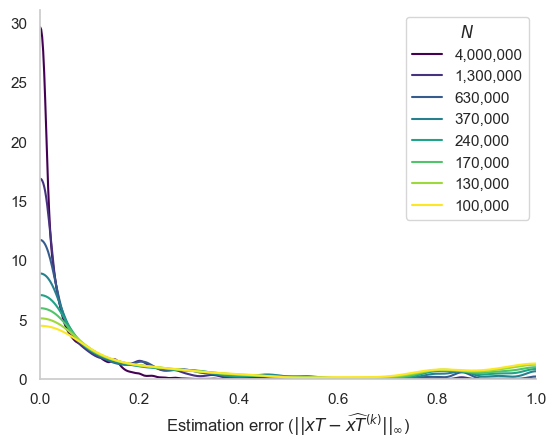

In [43]:
def bounded_bandwidth(data):
    """Scott's rule corrected for bounded support near 0."""
    n = len(data)
    # Use IQR-based spread instead of std, more robust near boundaries
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    std = min(data.std(), iqr / 1.34)
    return 0.9 * std * n**(-1/5)  # classic Silverman, but on robust spread

def reflected_kde(data, x_grid, bw=None):
    reflected = np.concatenate([data, -data, 2 - data])
    bw = bw or bounded_bandwidth(data)
    kde = gaussian_kde(reflected, bw_method=bw / reflected.std())
    return kde(x_grid) * 3

x_grid = np.linspace(0, 1, 500)
cmap_name = 'viridis'
cmap = matplotlib.colormaps[cmap_name]
hue_levels = np.sort(np.unique(df_errors['1/sqrt(N)']))

fig, ax = plt.subplots()

for i, level in enumerate(hue_levels):
    data = df_errors.loc[
        df_errors['1/sqrt(N)'] == level, 'xT_error_inf_norm'
    ].dropna().values
    color = cmap(
        (level - hue_levels.min()) / (hue_levels.max() - hue_levels.min())
    )
    density = reflected_kde(data, x_grid)
    ax.plot(x_grid, density, color=color)

# Legend
rounded = [f"{int(1/l**2):,}" for l in hue_levels]
handles = [
    matplotlib.lines.Line2D([0], [0], color=cmap(
        (l - hue_levels.min()) / (hue_levels.max() - hue_levels.min())
    )) for l in hue_levels
]
ax.legend(handles, rounded, title=r"$N$")
ax.set_xlabel(r"Estimation error ($||xT-\widehat{xT}^{(k)}||_\infty$)")
ax.set_xlim(0, max(1.0, df_errors['xT_error_inf_norm'].max()))
ax.set_ylim(0, None)
ax.spines[['top', 'right']].set_visible(False)
# ax.spines['bottom'].set_position(('data', 0))
ax.grid(False)
plt.show()

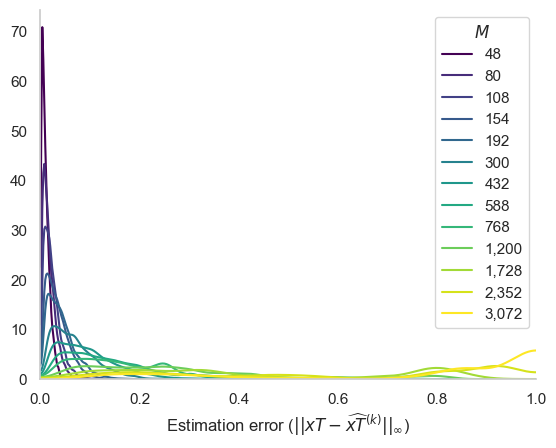

In [44]:
x_grid = np.linspace(0, 1, 500)
cmap_name = 'viridis'
cmap = matplotlib.colormaps[cmap_name]

# Use log(M) just like in the first plot
hue_levels = np.sort(np.unique(df_errors['M']))
log_levels = np.log(hue_levels)

fig, ax = plt.subplots()

for i, level in enumerate(hue_levels):
    data = df_errors.loc[
        df_errors['M'] == level, 'xT_error_inf_norm'
    ].dropna().values
    
    color = cmap(
        (np.log(level) - log_levels.min()) / (log_levels.max() - log_levels.min())
    )
    
    density = reflected_kde(data, x_grid)
    ax.plot(x_grid, density, color=color)

# Legend (same mapping!)
rounded = [f"{int(l):,}" for l in hue_levels]
handles = [
    matplotlib.lines.Line2D(
        [0], [0],
        color=cmap(
            (np.log(l) - log_levels.min()) / (log_levels.max() - log_levels.min())
        )
    )
    for l in hue_levels
]

ax.legend(handles, rounded, title=r"$M$")
ax.set_xlabel(r"Estimation error ($||xT-\widehat{xT}^{(k)}||_\infty$)")
ax.set_xlim(0, max(1.0, df_errors['xT_error_inf_norm'].max()))
ax.set_ylim(0, None)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)

plt.show()

In [45]:
np.sum(df_errors['M^{3/2}log(M)/sqrt(N)'] > 445)

np.int64(28000)

In [46]:
df_errors.shape

(104000, 28)

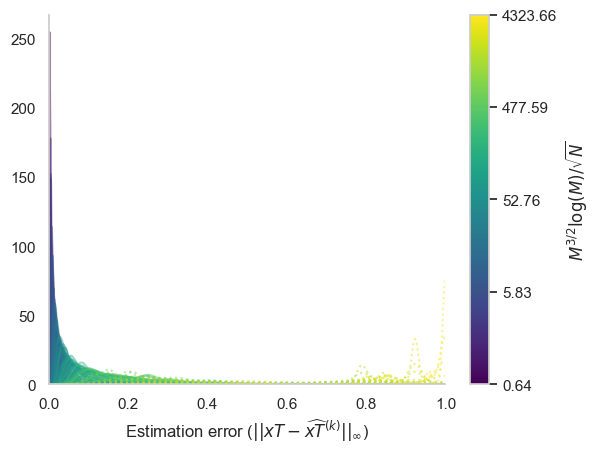

In [47]:
fig, ax = plt.subplots()

# Colorbar setup (log-normalized, continuous)
log_vals = np.log(df_errors['M^{3/2}log(M)/sqrt(N)'])
norm = plt.Normalize(log_vals.min(), log_vals.max())
sm_ = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm_.set_array([])
cmap = matplotlib.colormaps['viridis']

# Plot a KDE line per unique level
hue_levels = np.sort(np.unique(df_errors['M^{3/2}log(M)/sqrt(N)']))

x_grid = np.linspace(0, 1, 500)

for level in hue_levels:
    data = df_errors.loc[
        df_errors['M^{3/2}log(M)/sqrt(N)'] == level, 'xT_error_inf_norm'
    ].dropna().values

    log_level = np.log(level)
    color = cmap(norm(log_level))

    density = reflected_kde(data, x_grid)
    linestyle = 'solid' if level < 445 else 'dotted'  # Solid for small, dashed if filtered out
    ax.plot(x_grid, density, color=color, alpha=0.5, linestyle=linestyle)

# Colorbar
min_val = log_vals.min()
max_val = log_vals.max()
tick_positions = np.linspace(min_val, max_val, num=5)
tick_values = np.exp(tick_positions)

cbar = plt.colorbar(sm_, ax=ax, ticks=tick_positions)
cbar.set_ticklabels([f"{val:.2f}" for val in tick_values])
cbar.set_label(r"$M^{3/2}\log(M)/\sqrt{N}$")

ax.set_xlabel(r"Estimation error ($||xT-\widehat{xT}^{(k)}||_\infty$)")
ax.set_xlim(0, max(1.0, df_errors['xT_error_inf_norm'].max()))
ax.set_ylim(0, None)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)
plt.show()

# OLS Modeling

# Applying OLS to the filtered dataset

In [48]:
df_errors_ols = df_errors[df_errors['M^{3/2}log(M)/sqrt(N)'] < 445].copy()
df_errors_ols['sqrt(M)log(M)/sqrt(N)'] = df_errors_ols['log(M)/sqrt(N)'] * np.sqrt(df_errors_ols['M'])

                            OLS Regression Results                            
Dep. Variable:      xT_error_inf_norm   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                 2.416e+05
Date:                 do, 18 jun 2026   Prob (F-statistic):               0.00
Time:                        14:48:48   Log-Likelihood:                -42284.
No. Observations:               76000   AIC:                         8.457e+04
Df Residuals:                   75997   BIC:                         8.460e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.0916      0.017   -121.

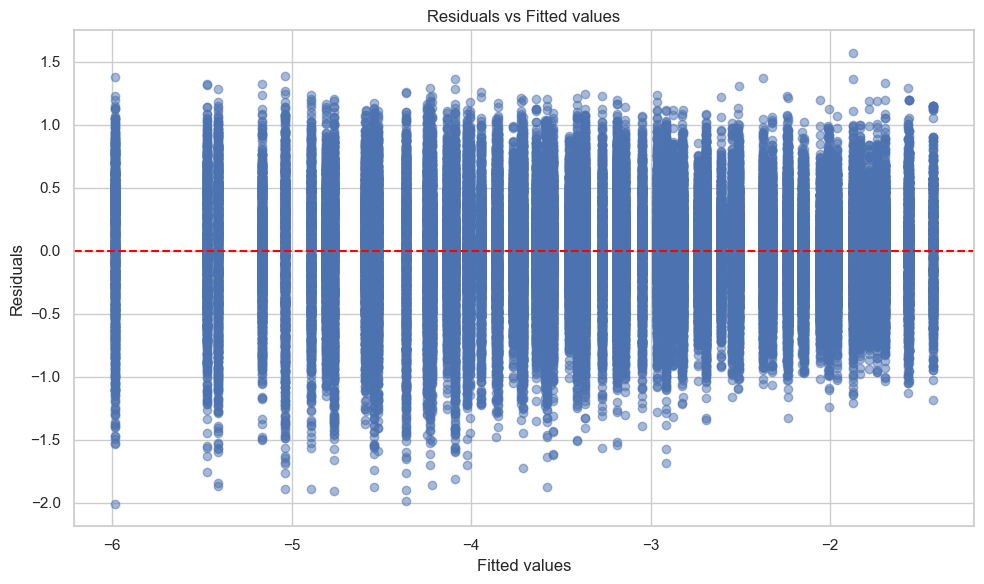

In [49]:
# Do OLS regression on log transformations

X = sm.add_constant(pd.DataFrame({
    'log(M)': np.log(df_errors_ols['M']),
    'log(1/sqrt(N))': -np.log(np.sqrt(df_errors_ols['N']))
    }))
Y = np.log(df_errors_ols['xT_error_inf_norm'])
# Fit the model
model = sm.OLS(Y,X)
results = model.fit()
print(results.summary())

# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values')
plt.grid(True)
plt.tight_layout()
plt.show()





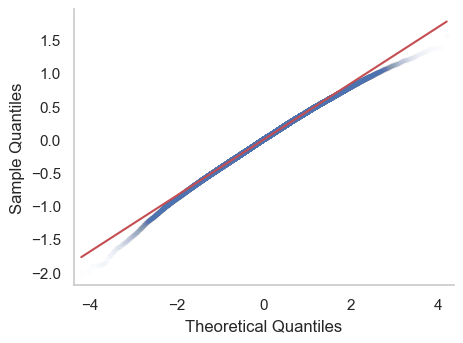

In [50]:
# Plot the QQ plot of the residuals
fig, ax = plt.subplots(figsize=(4.8, 3.6))
sm.qqplot(results.resid, line='s', ax = ax, alpha=0.01, markersize=3)
ax.grid(False)
plt.tight_layout()
ax.spines[['top', 'right']].set_visible(False)
plt.show()

In [51]:
c = results.params['const']
power = results.params['log(M)']
std_residuals = np.sqrt(results.mse_resid)
beta = results.params['log(1/sqrt(N))']
print(f"c={c}")
print(f"power={power}")
print(f"std_residuals={std_residuals}")
print(f"Variance residuals={results.mse_resid}")
print(f"beta={beta}")

c=-2.0915784326697198
power=1.0099919011379082
std_residuals=0.4220842476334173
Variance residuals=0.1781551121002679
beta=1.0266672599410456


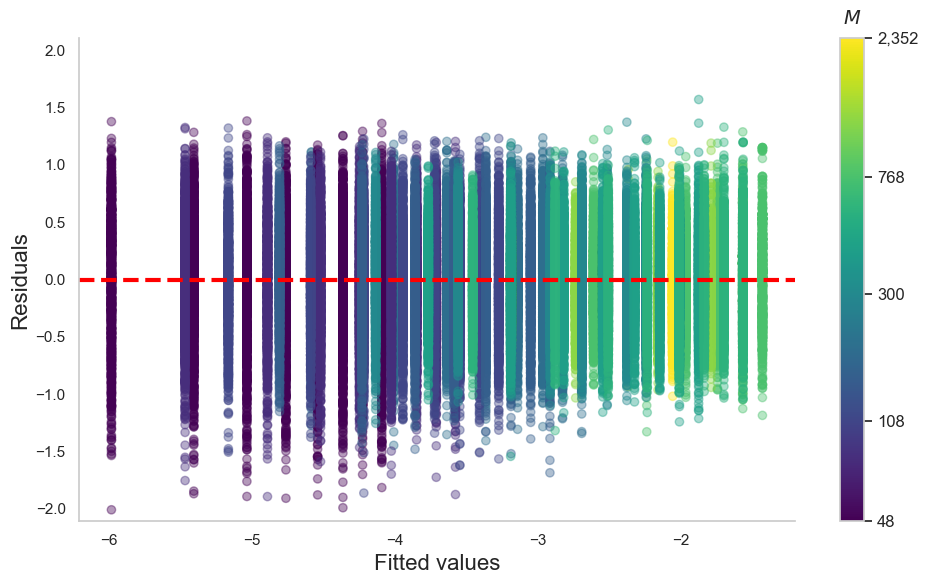

In [52]:
# Plot
fig, axes = plt.subplots(1, 1, figsize=(10,6))
sc = axes.scatter(results.fittedvalues, results.resid, c=np.log(df_errors_ols['M']), cmap='viridis', alpha=0.4)
axes.axhline(0, color='red', linestyle='--', linewidth=3)

cbar = plt.colorbar(sc)
cbar.solids.set_alpha(1)
ticks = np.log(np.quantile(df_errors_ols['M'], [0.0, 0.25, 0.6, 0.92, 1.0]))
cbar.set_ticks(ticks)

# — Apply exponential transform to tick labels —
def exp_formatter(x, pos):
    # as an integer
    return f"{int(np.round(np.exp(x))):,}"

cbar.formatter = FuncFormatter(exp_formatter)
cbar.update_ticks()

cbar.ax.set_title("$M$", pad=10, fontsize=14)
# plt.xticks(fontweight='bold', fontsize=12)
# plt.yticks(fontweight='bold', fontsize=12)
for label in cbar.ax.get_yticklabels():
    # label.set_fontweight('bold')
    label.set_fontsize(12)

plt.grid(False)
axes.spines[['top', 'right']].set_visible(False)
axes.set_ylim(-np.max(np.abs(results.resid))-0.1, np.max(np.abs(results.resid))+0.1)
axes.set_xlabel('Fitted values', fontsize=16)
axes.set_ylabel('Residuals', fontsize=16)
plt.tight_layout()
plt.show()


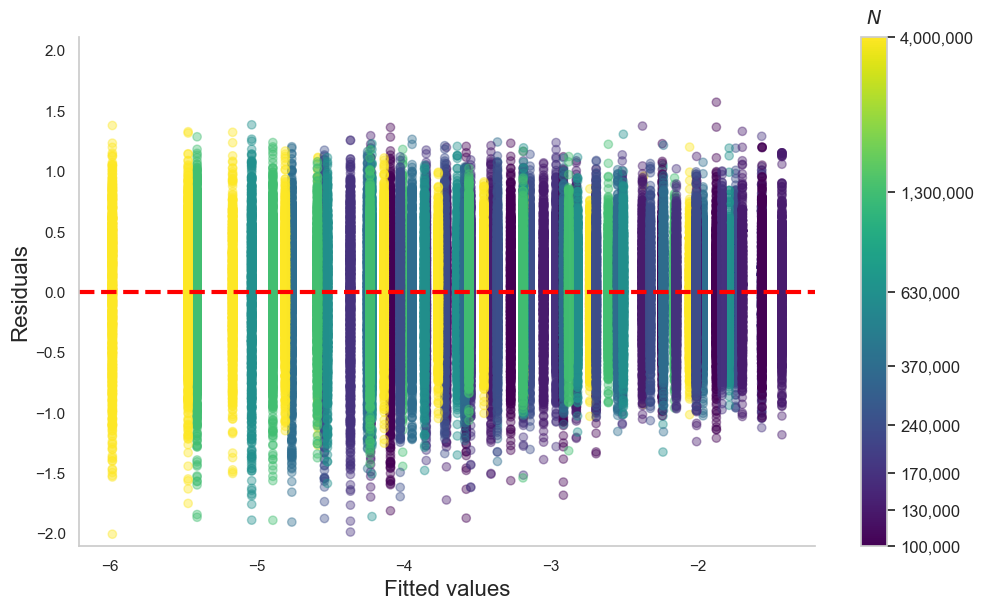

In [53]:
# Plot
fig, axes = plt.subplots(1, 1, figsize=(10,6))
sc = axes.scatter(results.fittedvalues, results.resid, c=np.log(df_errors_ols['N']), cmap='viridis', alpha=0.4)
axes.axhline(0, color='red', linestyle='--', linewidth=3)

cbar = plt.colorbar(sc)
cbar.solids.set_alpha(1)
ticks = np.log(np.quantile(df_errors_ols['N'], [0.0, 0.3, 0.5, 0.6, 0.75, 1.0]))
ticks = np.log(df_errors_ols['N'].unique().tolist())
cbar.set_ticks(ticks)


# — Apply exponential transform to tick labels —
def exp_formatter(x, pos):
    # as an integer
    return f"{int(np.round(np.exp(x))):,}"

cbar.formatter = FuncFormatter(exp_formatter)
cbar.update_ticks()

cbar.ax.set_title("$N$", pad=10, fontsize=14)
# plt.xticks(fontweight='bold', fontsize=12)
# plt.yticks(fontweight='bold', fontsize=12)
for label in cbar.ax.get_yticklabels():
    # label.set_fontweight('bold')
    label.set_fontsize(12)

plt.grid(False)
axes.spines[['top', 'right']].set_visible(False)
axes.set_ylim(-np.max(np.abs(results.resid))-0.1, np.max(np.abs(results.resid))+0.1)
plt.tight_layout()
axes.set_xlabel('Fitted values', fontsize=16)
axes.set_ylabel('Residuals', fontsize=16)
plt.show()


# Additional plots

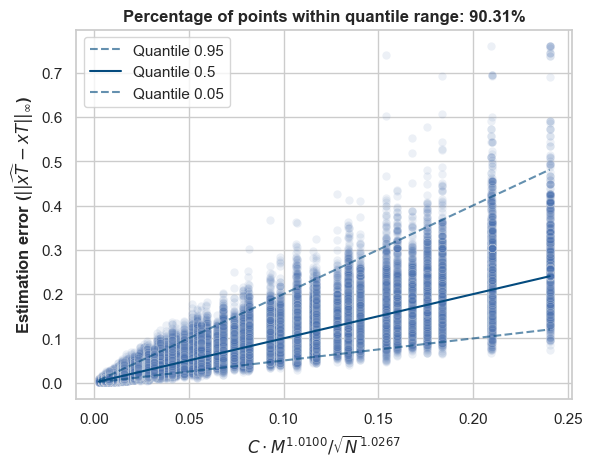

In [54]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))

xs = np.exp(c)*df_errors_ols['M']**power * df_errors_ols['1/sqrt(N)']**beta

sns.scatterplot(
    x=xs,
    y=df_errors_ols['xT_error_inf_norm'],
    ax=ax,
    alpha=0.1,
)

# Add quantiles
quantiles = [0.05, 0.5, 0.95]
linestyles = ['--', '-', '--']
colors = ['blue', 'darkblue', 'blue']
colors = ["#044b7e9d", "#044b7e", '#044b7e9d']


xs_plot = np.linspace(xs.min(), xs.max(), 1000)
for i, q in enumerate(quantiles[::-1]):
    quantile = lognorm.ppf(q, s=std_residuals, scale=xs_plot)
    plt.plot(xs_plot, quantile, label=f'Quantile {q}', linestyle=linestyles[i], color=colors[i])

ax.set_xlabel(r'$C\cdot M^{%.4f} / \sqrt{N}^{%.4f}$' % (power, beta), weight='bold')
ax.set_ylabel(r'Estimation error ($||\widehat{xT} - xT||_{\infty}$)', weight='bold')

# Calculate the number of points within the quantile range
within_quantile = df_errors_ols[
    (df_errors_ols['xT_error_inf_norm'] >= lognorm.ppf(0.05, s=std_residuals, scale=xs)) &
    (df_errors_ols['xT_error_inf_norm'] <= lognorm.ppf(0.95, s=std_residuals, scale=xs))
]

within_quantile_count = len(within_quantile)
plt.title(f'Percentage of points within quantile range: {within_quantile_count/len(xs)*100:.2f}%', weight='bold')
# Make it an annotation
# plt.annotate(
#     f'Percentage of points within quantile range: {within_quantile_count/len(xs)*100:.2f}%',
#     xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, ha='left', va='top',
#     bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white')
# )

plt.legend()

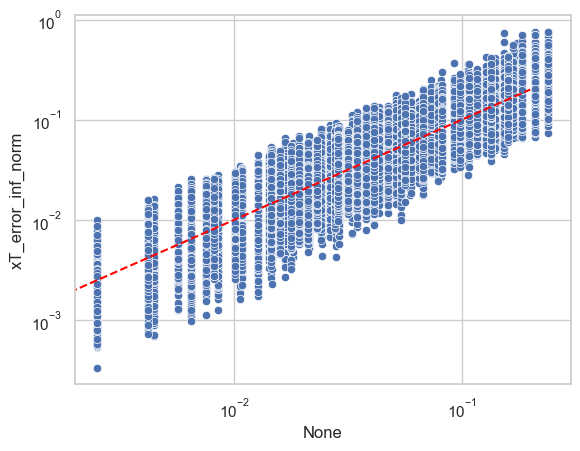

In [55]:
fig, ax =  plt.subplots(figsize=(6.4, 4.8))
ax.set(xscale='log', yscale='log')
sns.scatterplot(
    x=np.exp(results.fittedvalues),
    y=df_errors_ols['xT_error_inf_norm'],
    ax=ax,
)
# Add line y=x
plt.plot([0, 0.2], [0, 0.2], color='red', linestyle='--', label='y=x')